<a href="https://colab.research.google.com/github/devrenanzin/TRABALHO-SISTEMA-DE-CONTROLE-INTELIGENTE2/blob/main/trabalho_da_lele_maravilha_pds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#IMPORTANDO BIBLIOTECAS

from google.colab import drive
import random
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import firwin, filtfilt, butter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



In [2]:

#  Montar Google Drive e definir pasta

drive.mount('/content/drive')

# Caminho da pasta com os arquivos .csv
# -> depois de criar o atalho da pasta "test" em Meu Drive
caminho_pasta = '/content/drive/MyDrive/test'  # ajuste se o nome for outro

# Lista de arquivos .csv na pasta
arquivos = sorted([f for f in os.listdir(caminho_pasta) if f.endswith('.csv')])

if len(arquivos) == 0:
    raise RuntimeError("Nenhum arquivo .csv encontrado na pasta especificada.")


Mounted at /content/drive


In [3]:


#  Parâmetros gerais e filtros

fs = 20000          # taxa de amostragem (Hz)
cutoff_lp = 3000    # frequência de corte FIR passa-baixa (Hz)
cutoff_hp = 500     # frequência de corte IIR passa-alta (Hz)

# FIR passa-baixa
ordem_fir = 50
taps = firwin(ordem_fir, cutoff_lp, fs=fs, pass_zero='lowpass')

# IIR Butterworth passa-alta
ordem_iir = 2
wn = cutoff_hp / (fs / 2.0)
b_butter, a_butter = butter(ordem_iir, wn, btype='highpass')




In [4]:
# Funções de plot

def plot_sinais_tempo(t, x, x_fir, x_iir, arquivo):
    """Plota sinal original, FIR e IIR no tempo."""
    fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    axs[0].plot(t, x, linewidth=0.8)
    axs[0].set_title(f"{arquivo} – Sinal Original")
    axs[0].set_ylabel("Amp. (norm.)")
    axs[0].grid(True)

    axs[1].plot(t, x_fir, color='red', linewidth=0.8)
    axs[1].set_title("Sinal Filtrado – FIR Passa-Baixa")
    axs[1].set_ylabel("Amplitude")
    axs[1].grid(True)

    axs[2].plot(t, x_iir, color='green', linewidth=0.8)
    axs[2].set_title("Sinal Filtrado – IIR Passa-Alta (Butterworth)")
    axs[2].set_xlabel("Tempo (s)")
    axs[2].set_ylabel("Amplitude")
    axs[2].grid(True)

    fig.suptitle(f"Sinais no Tempo – {arquivo}", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()


def plot_fft_zoom(freqs_pos, X_pos, Xfir_pos, Xiir_pos, arquivo):
    """Plota FFT com janelinhas de zoom embutidas."""
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    # Original
    axs[0].plot(freqs_pos, X_pos)
    axs[0].set_title("Original")
    axs[0].set_xlabel("Hz")
    axs[0].set_ylabel("Magnitude")
    axs[0].grid(True)

    zoom1 = inset_axes(axs[0], width="45%", height="40%", loc='upper right')
    zoom1.plot(freqs_pos, X_pos)
    zoom1.set_xlim(0, 1000)  # ajuste se quiser outra faixa
    zoom1.grid(True)

    # FIR
    axs[1].plot(freqs_pos, Xfir_pos, color='red')
    axs[1].set_title("FIR")
    axs[1].set_xlabel("Hz")
    axs[1].grid(True)

    zoom2 = inset_axes(axs[1], width="45%", height="40%", loc='upper right')
    zoom2.plot(freqs_pos, Xfir_pos, color='red')
    zoom2.set_xlim(2500, 3500)  # região perto do cutoff_lp
    zoom2.grid(True)

    # IIR
    axs[2].plot(freqs_pos, Xiir_pos, color='green')
    axs[2].set_title("IIR")
    axs[2].set_xlabel("Hz")
    axs[2].grid(True)

    zoom3 = inset_axes(axs[2], width="45%", height="40%", loc='upper right')
    zoom3.plot(freqs_pos, Xiir_pos, color='green')
    zoom3.set_xlim(100, 1000)  # enfatiza baixas frequências
    zoom3.grid(True)

    fig.suptitle(f"FFT com Zoom – {arquivo}", fontsize=14, weight='bold')
    plt.show()




In [5]:
# Selecionar até 10 arquivos aleatórios

qtd_arquivos = min(10, len(arquivos))
arquivos_escolhidos = random.sample(arquivos, qtd_arquivos)

print("Arquivos selecionados:")
for a in arquivos_escolhidos:
    print(" -", a)



Arquivos selecionados:
 - seg_1f7cf8.csv
 - seg_69a230.csv
 - seg_0cb81b.csv
 - seg_6b2ce0.csv
 - seg_123dd4.csv
 - seg_130e17.csv
 - seg_fea3e2.csv
 - seg_8d6578.csv
 - seg_b5aee9.csv
 - seg_74537f.csv


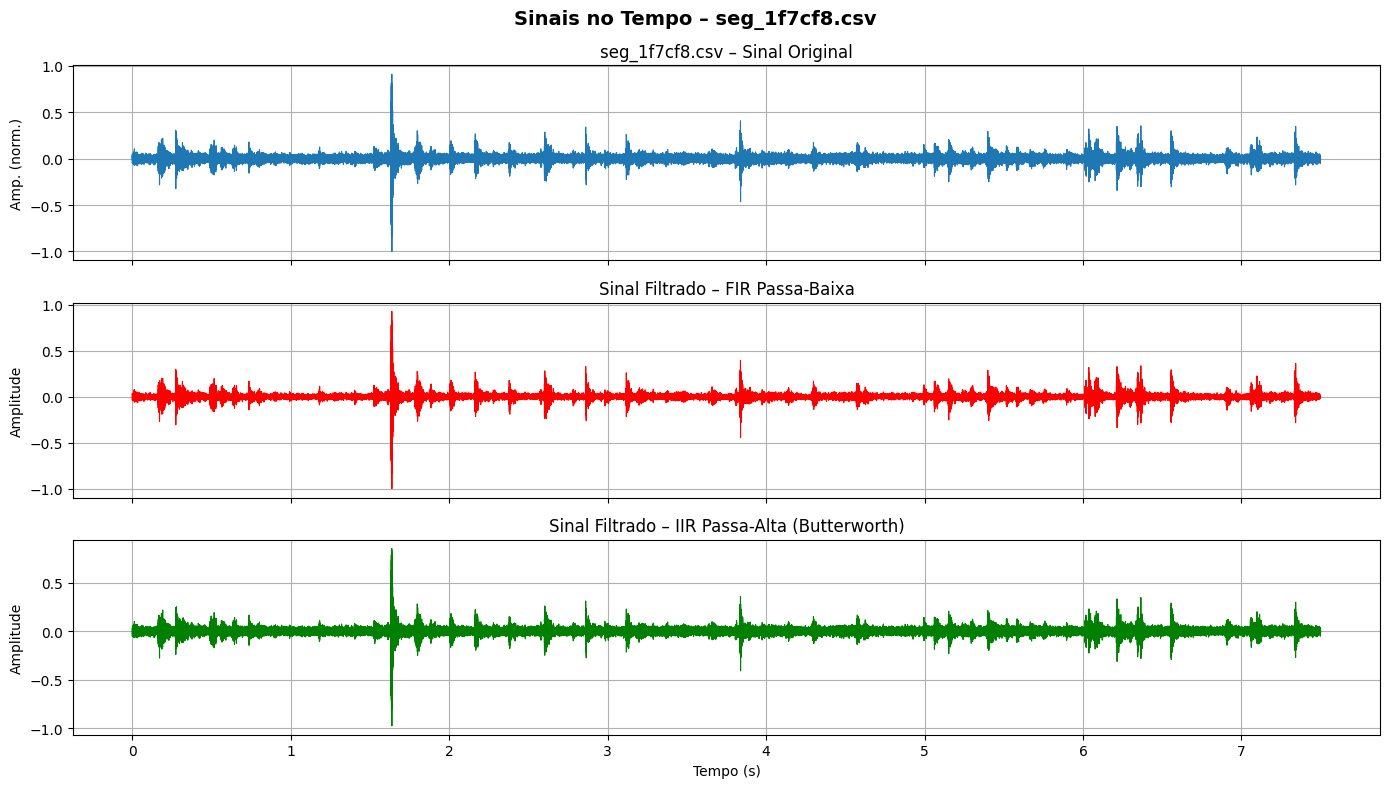

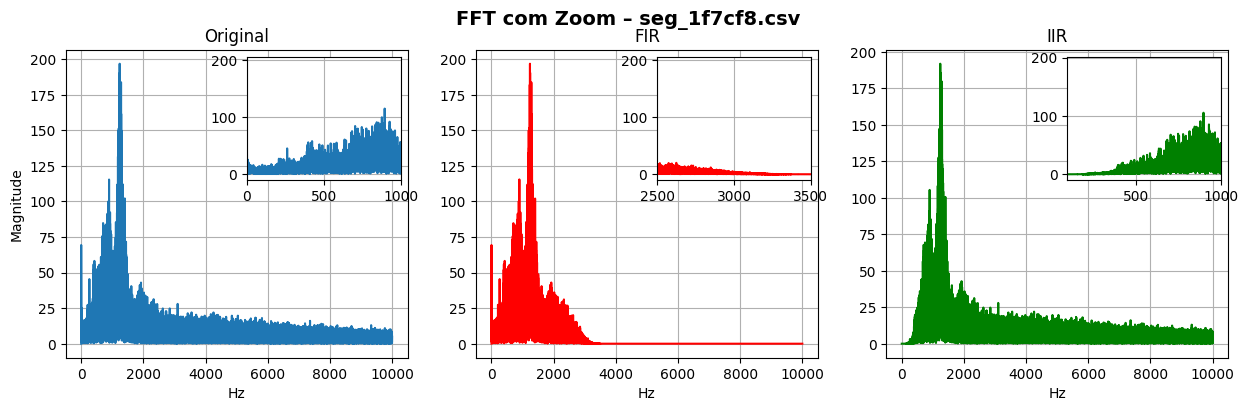

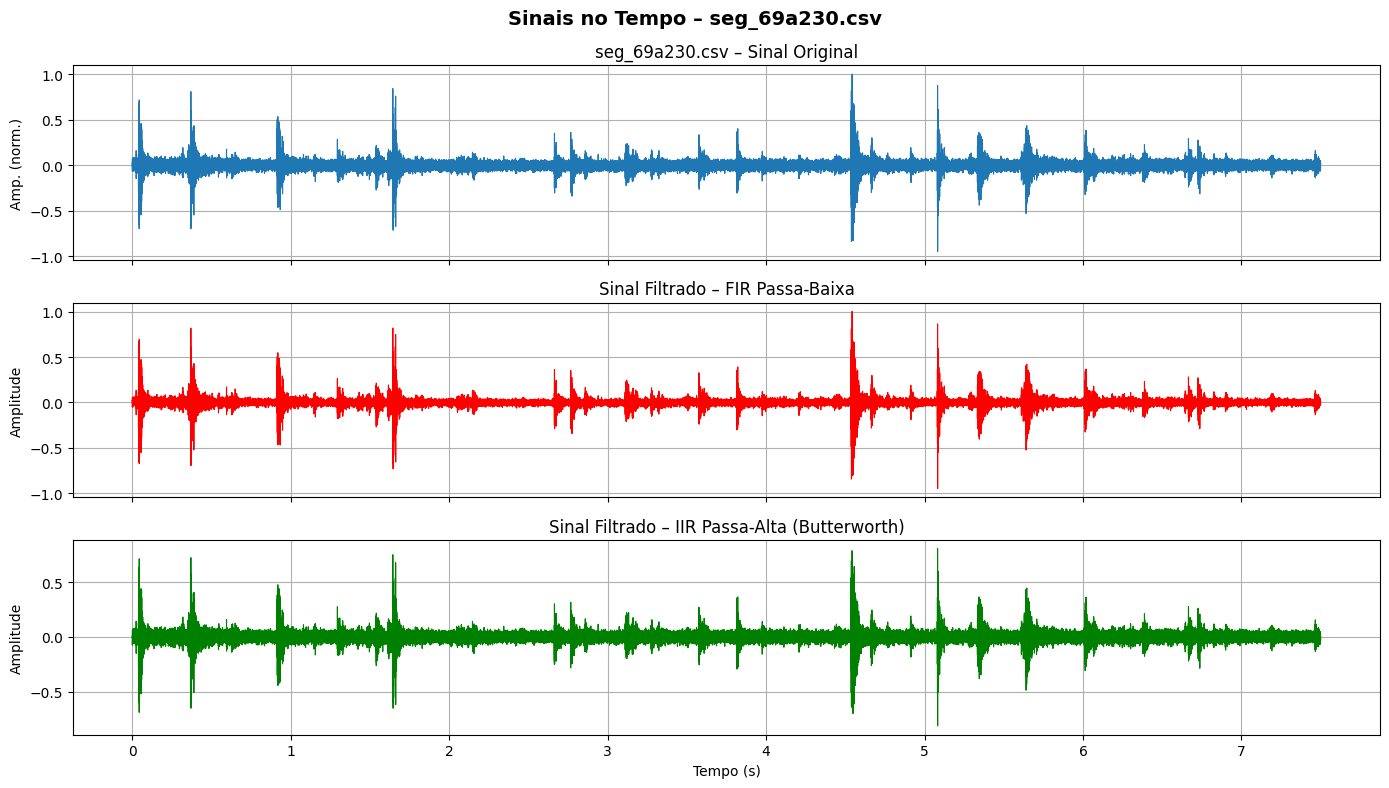

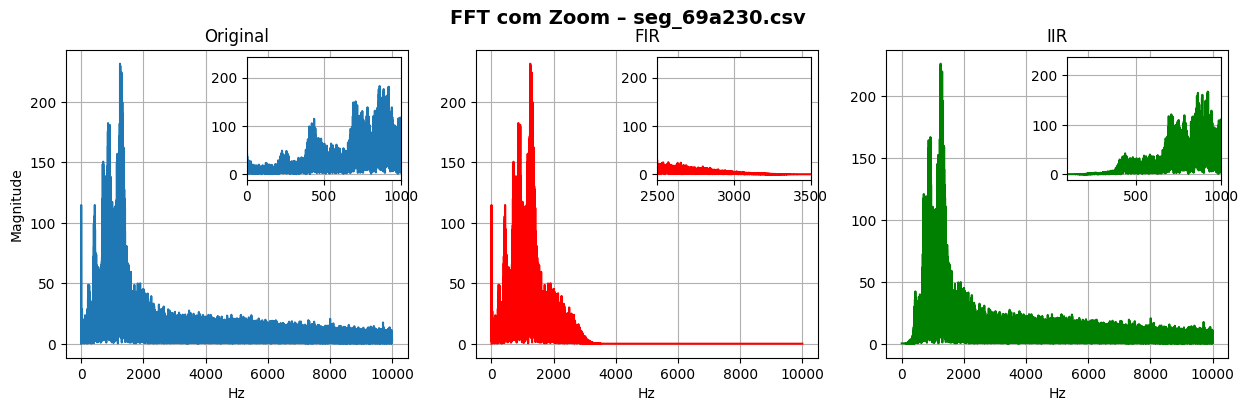

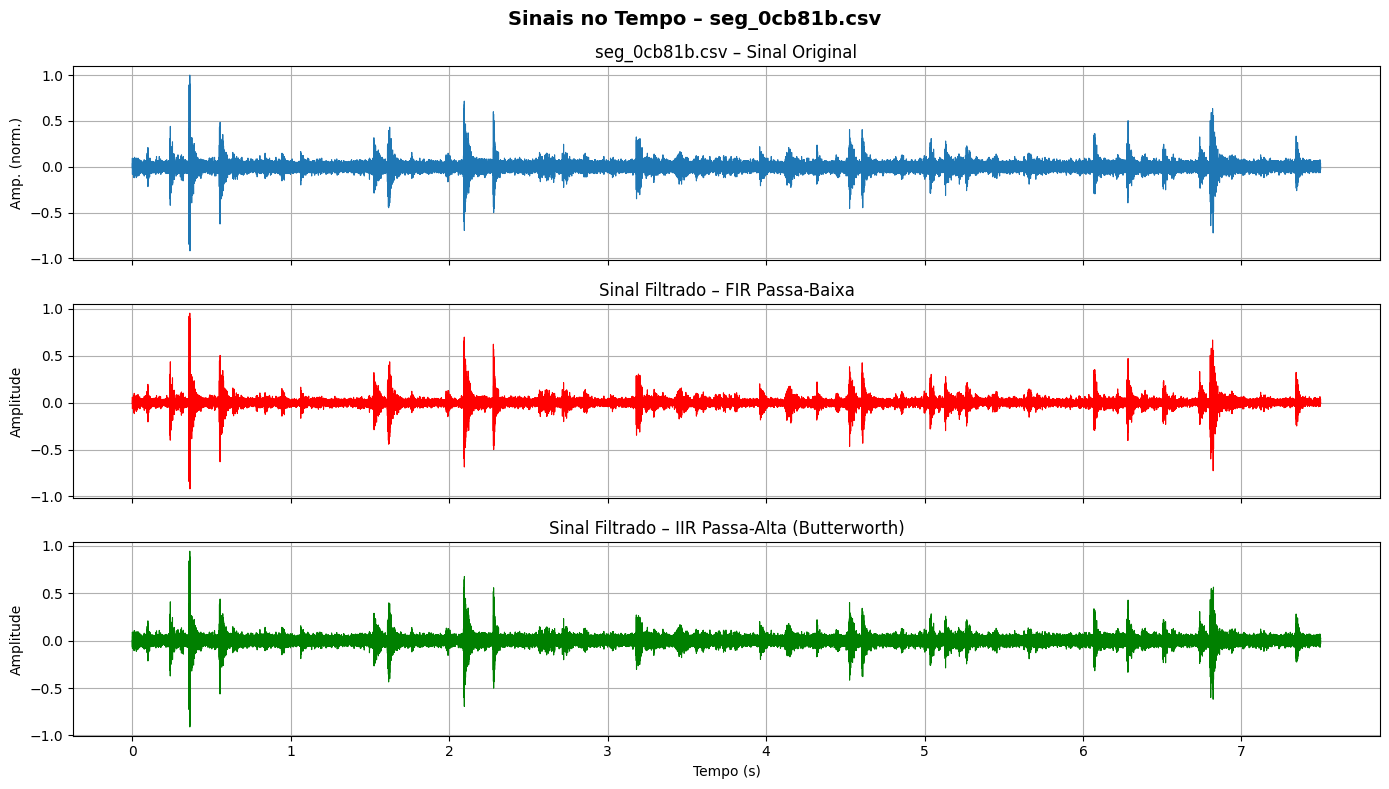

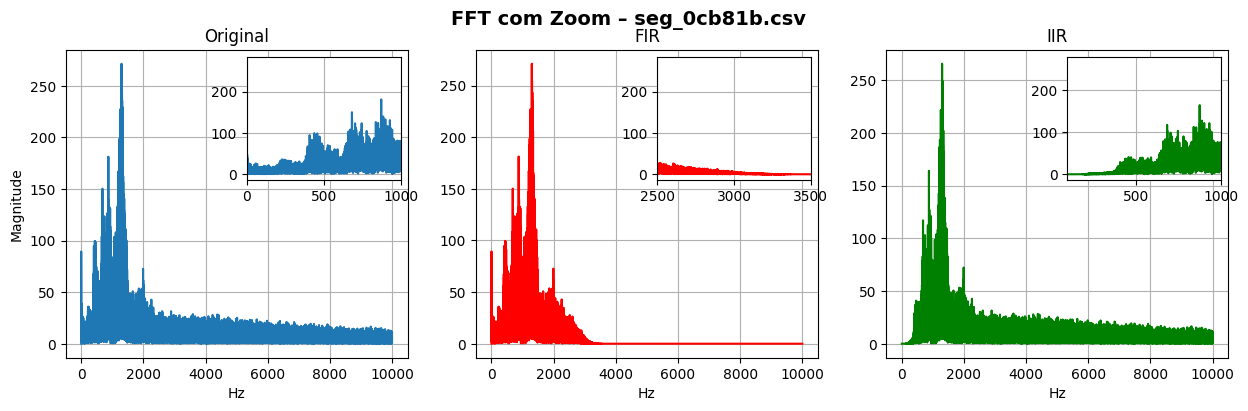

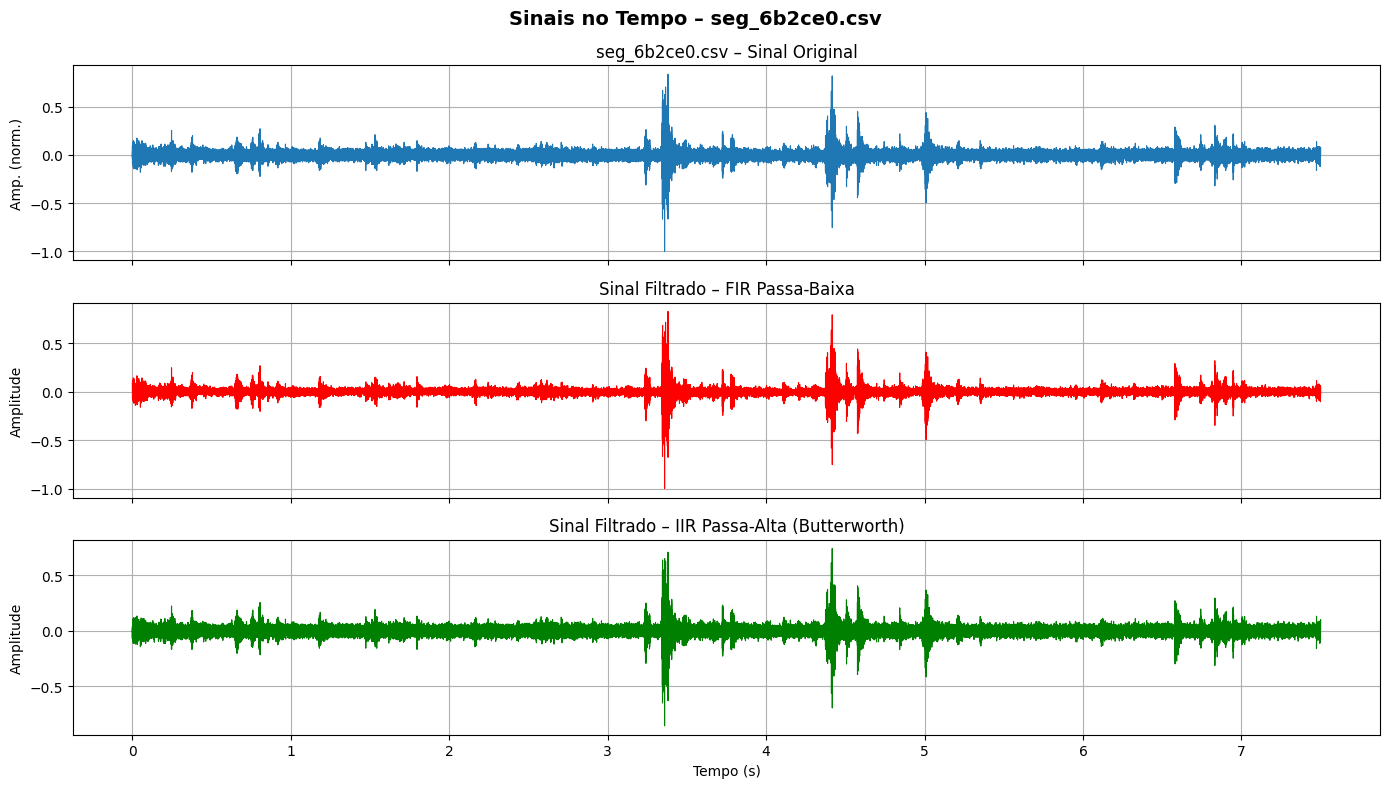

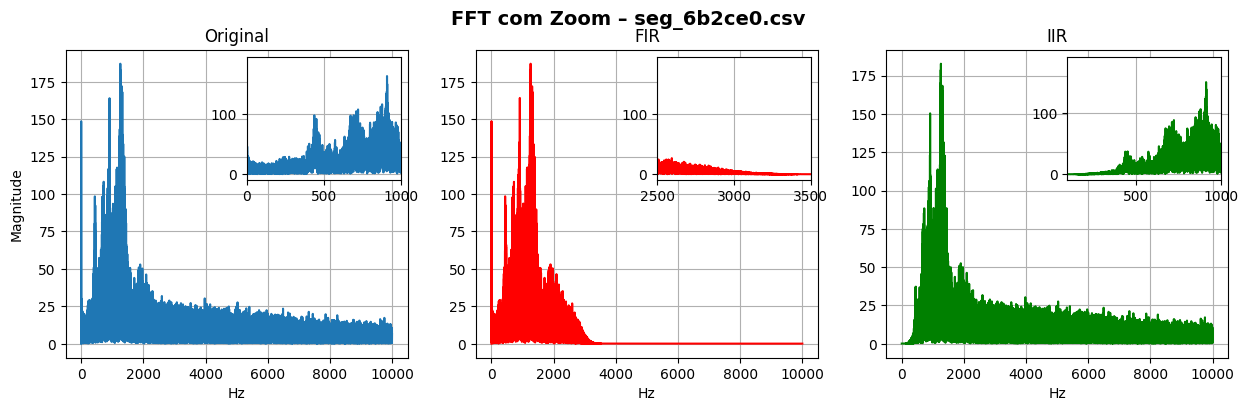

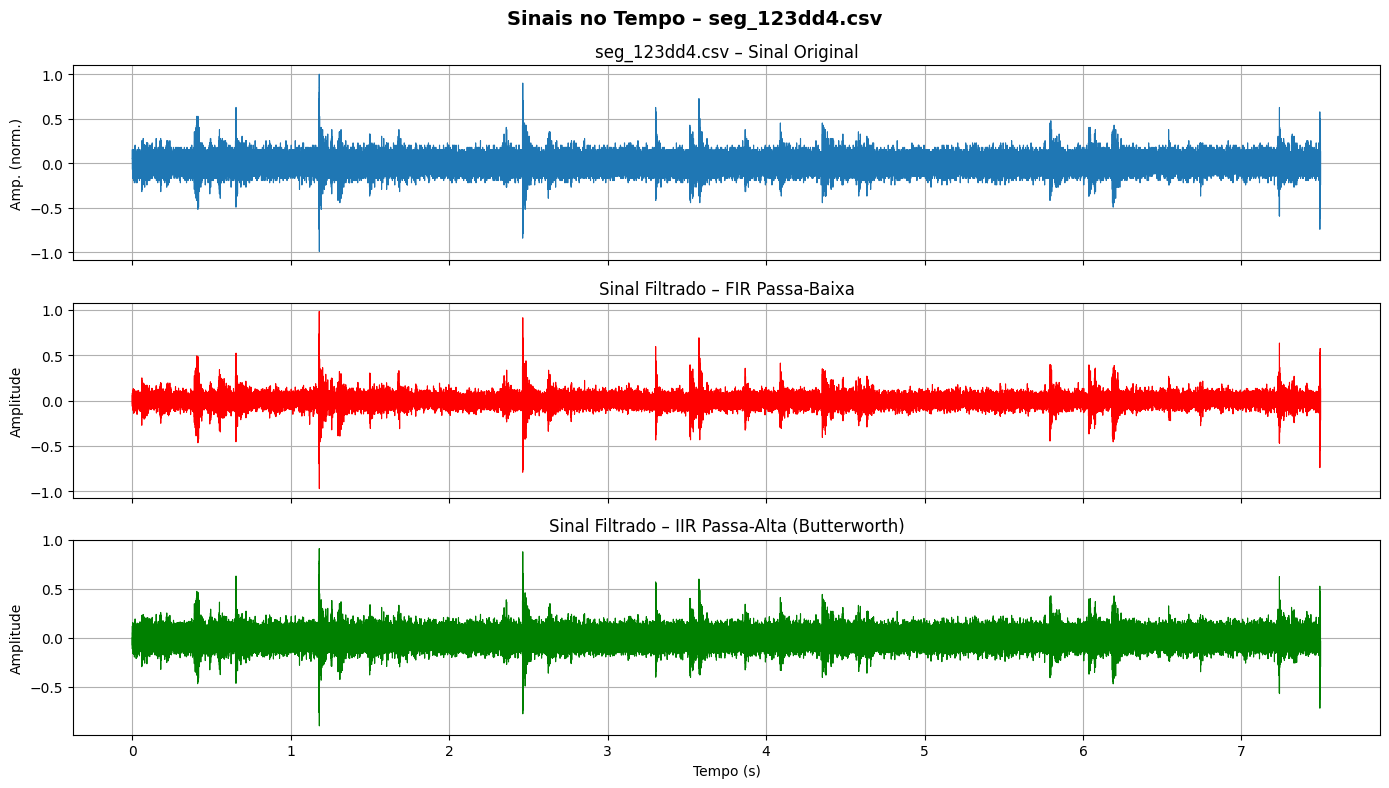

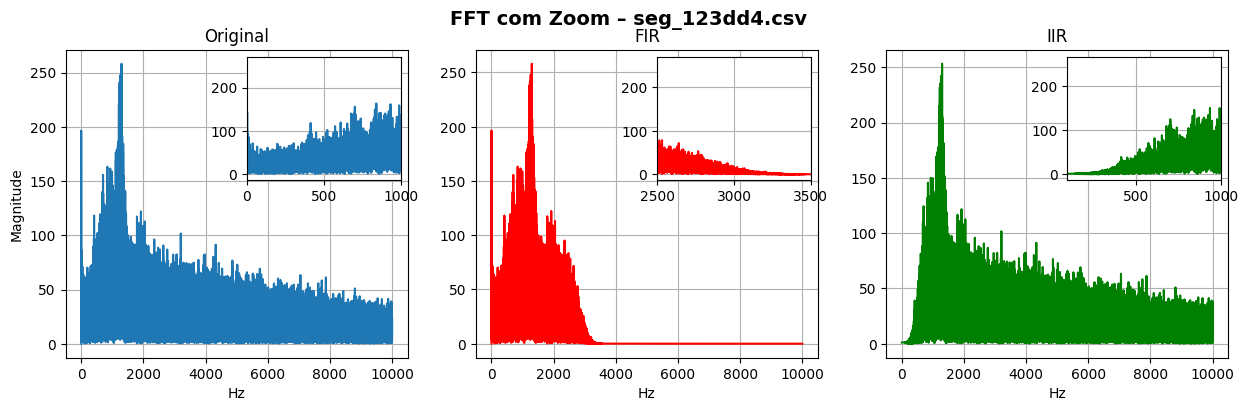

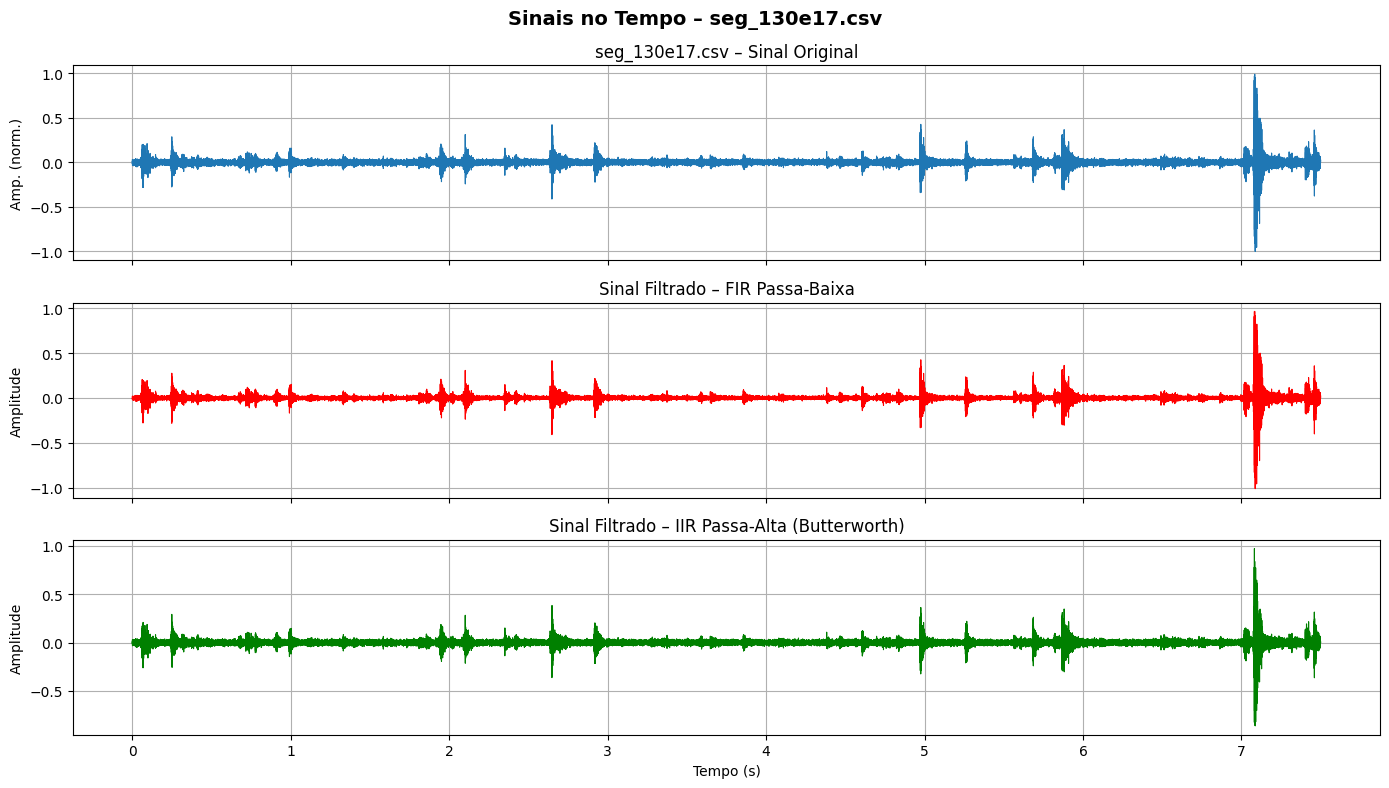

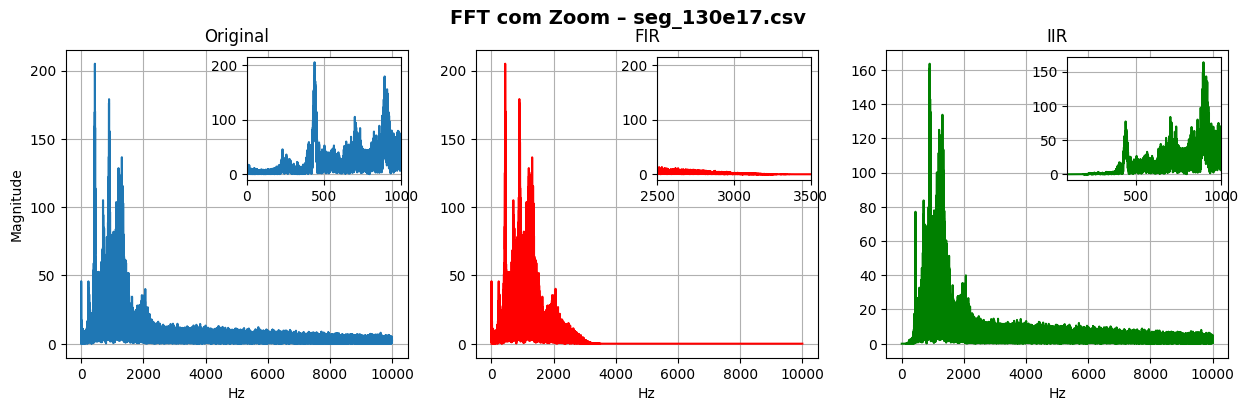

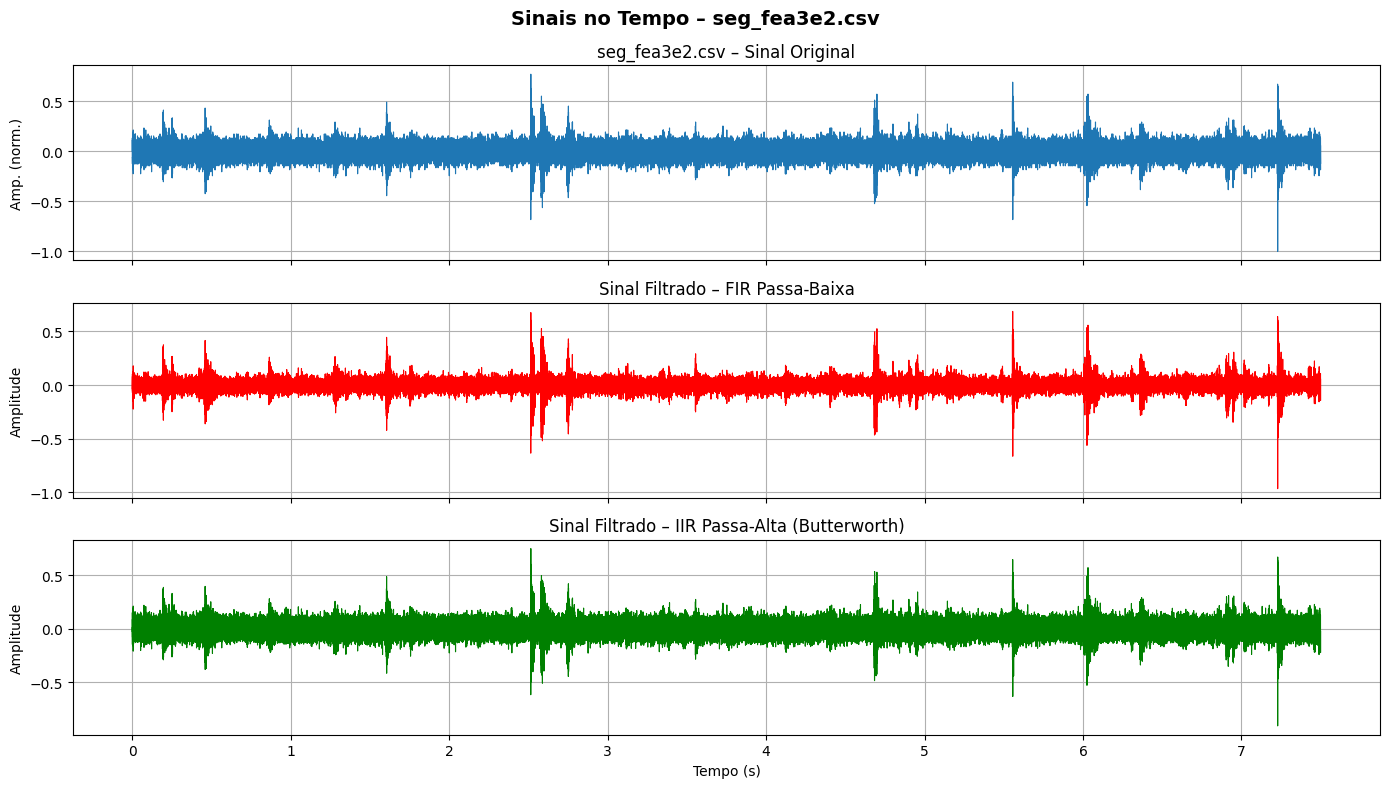

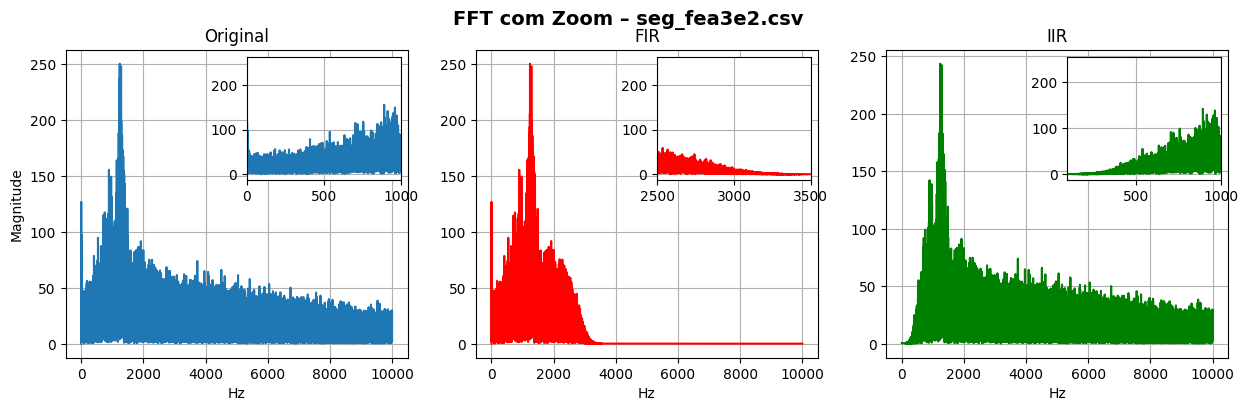

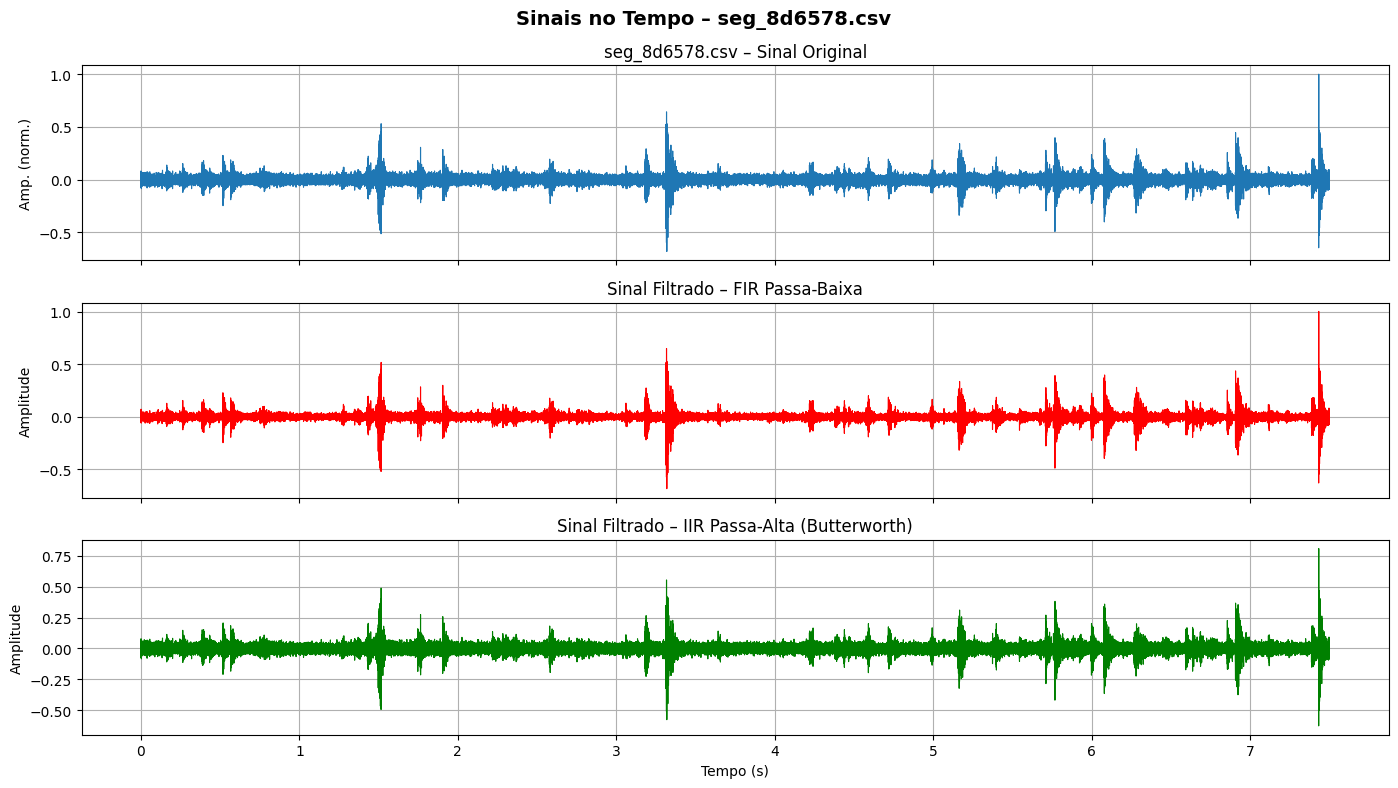

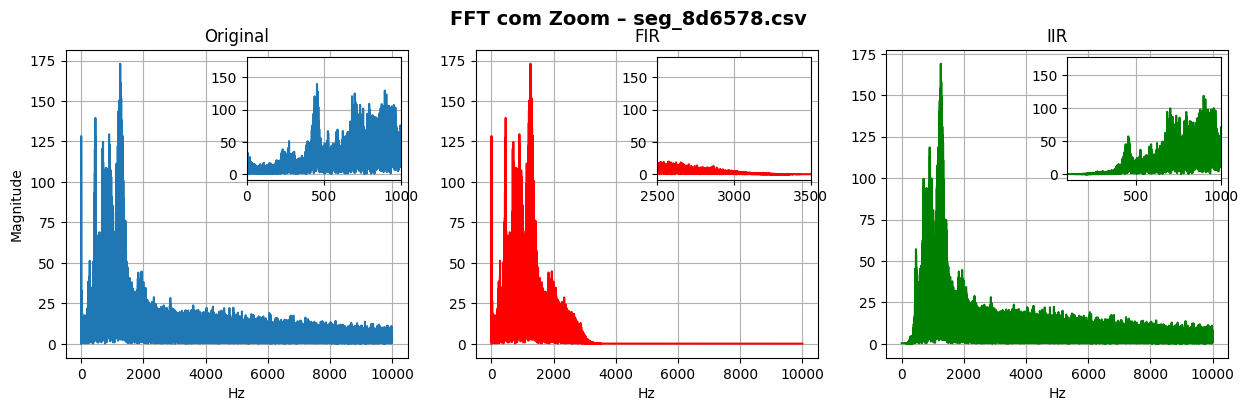

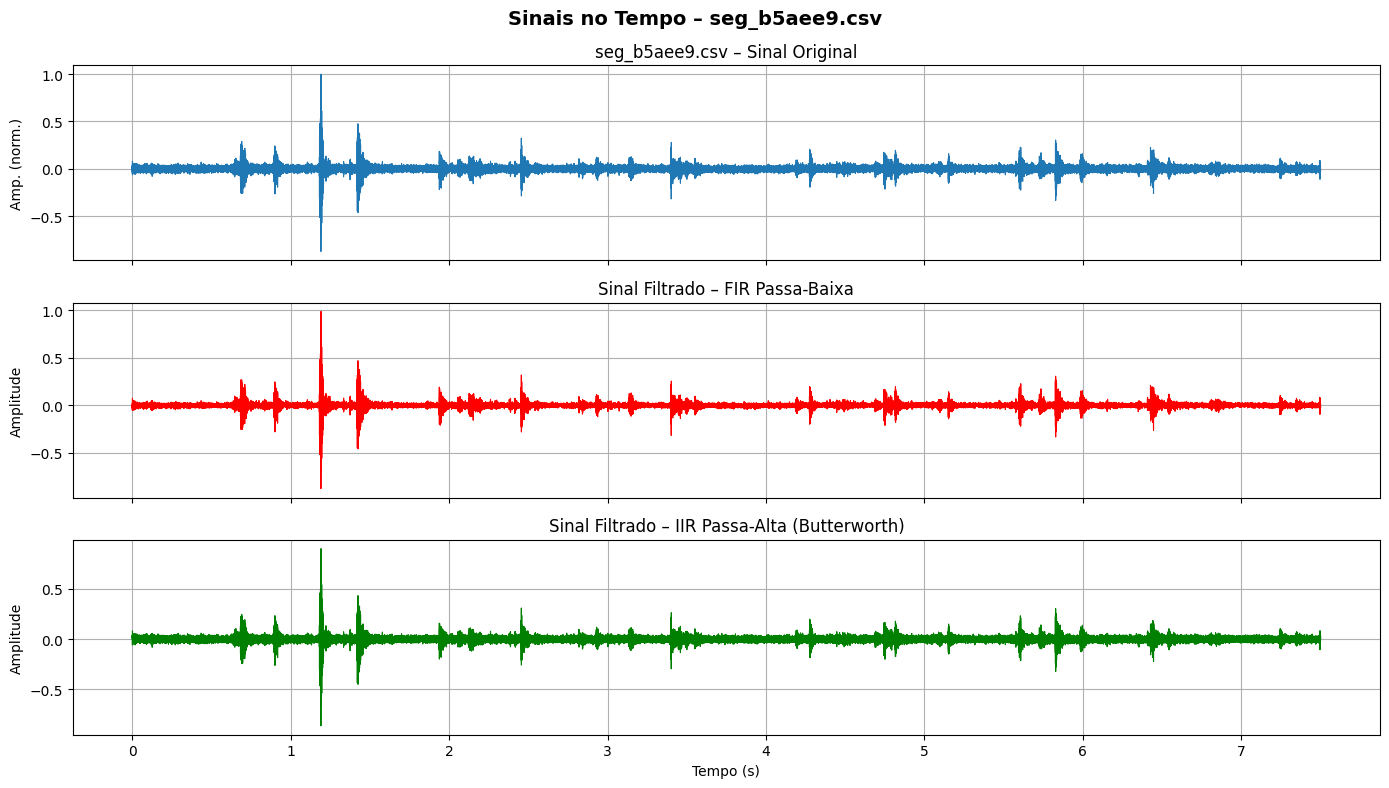

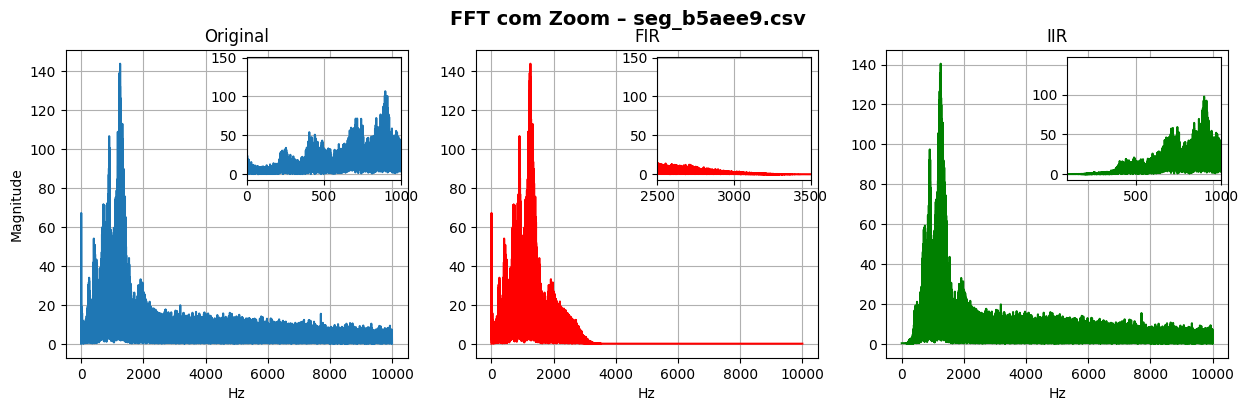

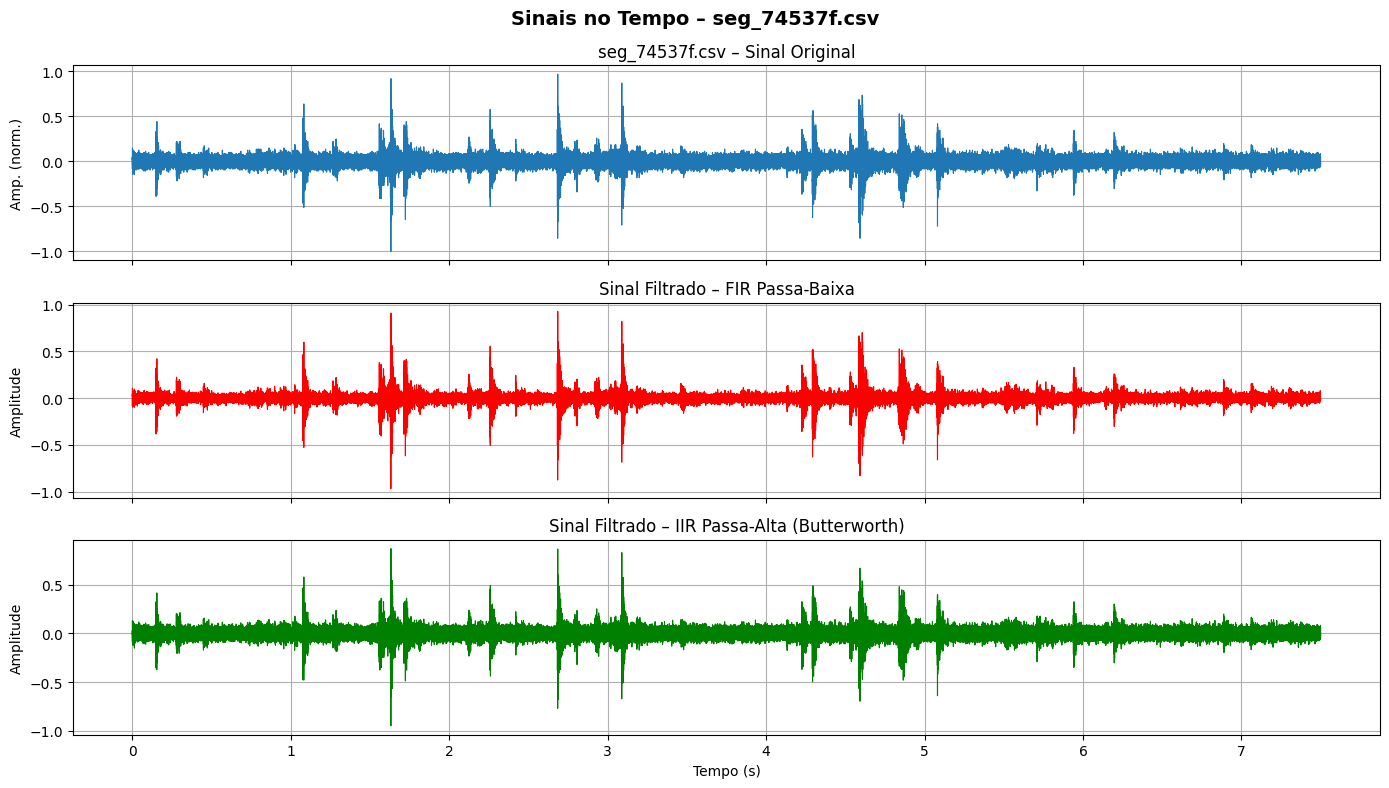

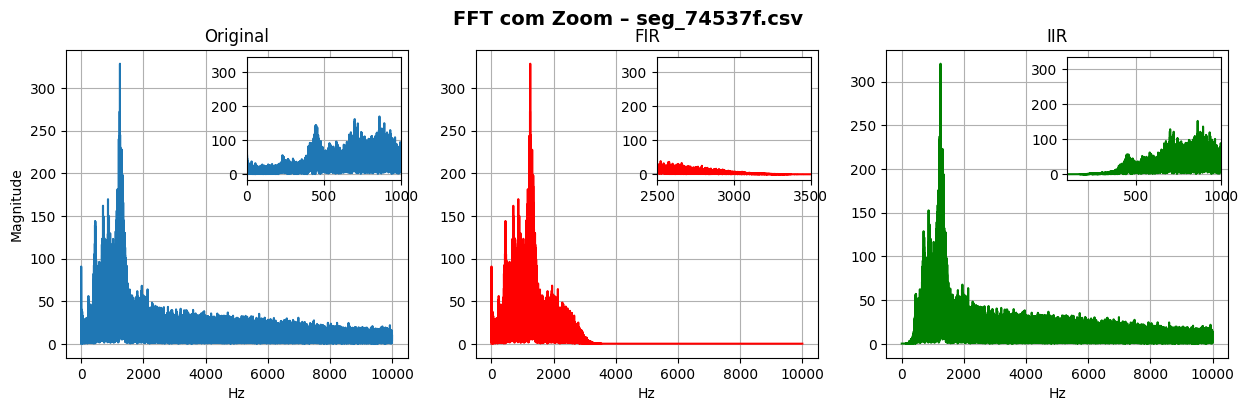

In [6]:
#  Loop principal sobre os arquivos

for arquivo in arquivos_escolhidos:

    caminho = os.path.join(caminho_pasta, arquivo)
    df = pd.read_csv(caminho)

    if 'acoustic_data' not in df.columns:
        print(f"Arquivo {arquivo} não contém a coluna 'acoustic_data'. Pulando...")
        continue

    # vetor de sinal
    x = df['acoustic_data'].values.astype(float)

    # -------- NORMALIZAÇÃO --------
    x = x - np.mean(x)               # remove nível DC
    max_abs = np.max(np.abs(x))
    if max_abs != 0:
        x = x / max_abs              # normaliza para [-1, 1]
    else:
        print(f"Sinal do arquivo {arquivo} é todo zero após remoção de DC.")
    # ------------------------------

    # eixo de tempo
    t = np.arange(len(x)) / fs

    # filtros
    x_fir = filtfilt(taps, 1.0, x)
    x_iir = filtfilt(b_butter, a_butter, x)

    # ---- gráficos no tempo
    plot_sinais_tempo(t, x, x_fir, x_iir, arquivo)

    # ---- FFTs
    N = len(x)
    X_full    = np.fft.fft(x)
    Xfir_full = np.fft.fft(x_fir)
    Xiir_full = np.fft.fft(x_iir)
    freqs_full = np.fft.fftfreq(N, d=1/fs)

    half = N // 2
    freqs_pos = freqs_full[:half]
    X_pos     = np.abs(X_full[:half])
    Xfir_pos  = np.abs(Xfir_full[:half])
    Xiir_pos  = np.abs(Xiir_full[:half])

    # gráficos de FFT
    plot_fft_zoom(freqs_pos, X_pos, Xfir_pos, Xiir_pos, arquivo)